In [28]:
import random
from pathlib import Path
import seaborn as sns
import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt
from omegaconf import OmegaConf
from rdkit import Chem
from rdkit.Chem.Scaffolds import MurckoScaffold
from rdkit.Chem import rdFingerprintGenerator
from rdkit.Chem import AllChem, DataStructs
from rdkit.Chem import MACCSkeys
import torch_geometric.data as gd
from torch_geometric.loader import DataLoader
from gflownet.proxy.mol_utils import smiles2graph, random_split
from gflownet.utils.sqlite_log import read_all_results
from gflownet.utils.conditioning import TemperatureConditional
from gflownet.models.graph_transformer import GraphTransformerGFN
from gflownet.algo.trajectory_balance import TrajectoryBalance
from gflownet.algo.flow_matching import FlowMatching
from gflownet.envs.graph_building_env import GraphBuildingEnv
from gflownet.envs.frag_mol_env import FragMolBuildingEnvContext
from gflownet.models import bengio2021flow
from utils import obtain_run, load_proxy_sol,  create_dir, scale_rew, infer_model
from scipy.stats import pearsonr, spearmanr

### Distribution plots for beta

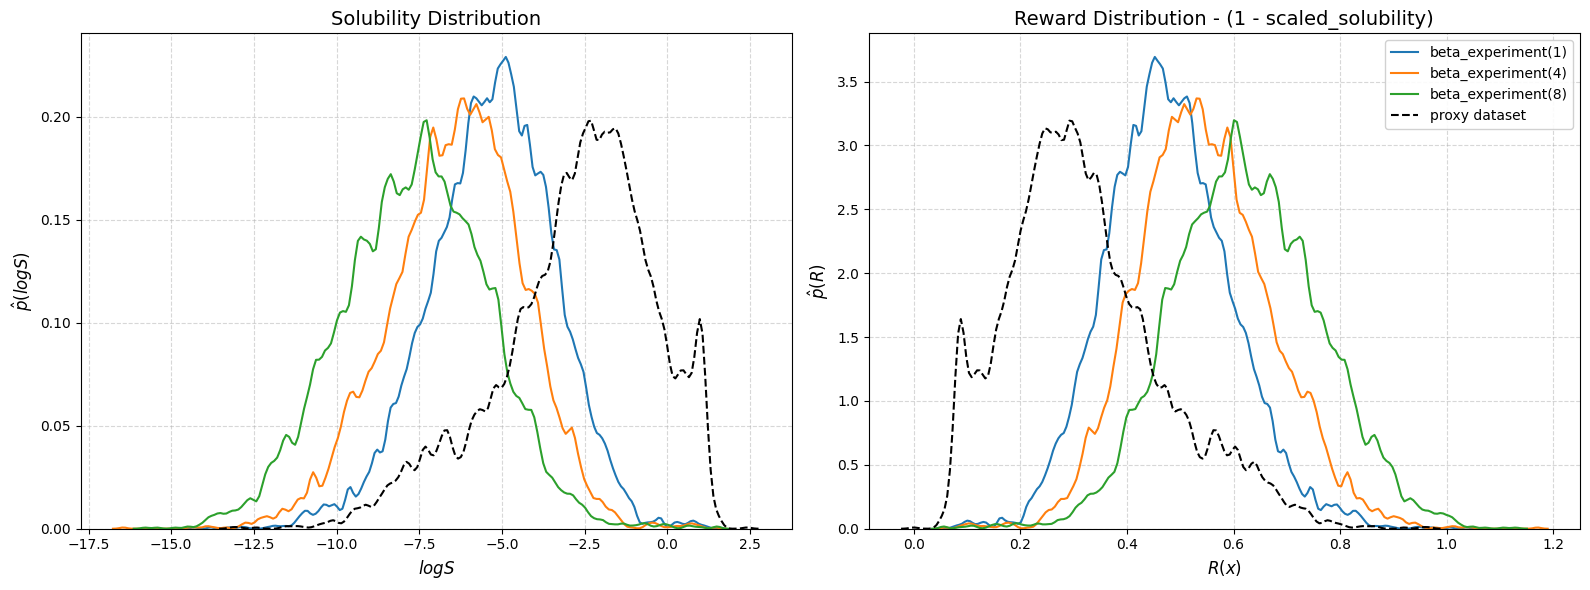

In [2]:
### Distribution plots for beta
data_url = r"https://raw.githubusercontent.com/CesareWang/Predictors-for-15-Environmental-Endpoints/main/predictors/data/SW.csv"
sol_data = pd.read_csv(data_url, index_col=0)
unscaled_data = list(sol_data["active"])
rew_data = scale_rew(list(sol_data["active"]))
sol_smiles = list(sol_data["smiles"])
ids = ["beta_experiment(1)", "beta_experiment(4)", "beta_experiment(8)"]
# create_dir("results")
# pl_dir = create_dir("results/dist_plots")
# Get predictions
sol_predictor = load_proxy_sol()
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].grid(True, linestyle="--", alpha=0.5)
axes[1].grid(True, linestyle="--", alpha=0.5)
palette = sns.color_palette("tab10")
linewidth = 1.5
# Right subplot
for id in ids:
    run_path = obtain_run(id)
    results = read_all_results(run_path / "final")
    smiles = list(results["smi"])
    reward = list(results["r"])
    graphs = [smiles2graph(Chem.MolFromSmiles(smile)) for smile in smiles]
    graph_loader = DataLoader(graphs, batch_size=1024, shuffle=False, pin_memory=True)
    sol_preds = infer_model(sol_predictor, graph_loader)
    sns.kdeplot(
        reward,
        bw_adjust=0.30,
        linestyle="-",
        label=id,
        linewidth=linewidth,
        ax=axes[1],
    )
    sns.kdeplot(
        sol_preds,
        bw_adjust=0.30,
        linestyle="-",
        label=f"{id}",
        linewidth=linewidth,
        ax=axes[0],
    )

sns.kdeplot(
    rew_data,
    bw_adjust=0.30,
    label="proxy dataset",
    color="black",
    linestyle="--",
    linewidth=linewidth,
    ax=axes[1],
)

sns.kdeplot(
    unscaled_data,
    bw_adjust=0.30,
    label="proxy dataset",
    color="black",
    linestyle="--",
    linewidth=linewidth,
    ax=axes[0],
)

axes[0].set_title("Solubility Distribution", fontsize=14)
axes[0].set_xlabel(r"$logS$", fontsize=12)
axes[0].set_ylabel(r"$\hat{p}(logS)$", fontsize=12)

axes[1].set_title("Reward Distribution - (1 - scaled_solubility)", fontsize=14)
axes[1].set_xlabel(r"$R(x)$", fontsize=12)
axes[1].set_ylabel(r"$\hat{p}(R)$", fontsize=12)
axes[1].legend(fontsize=10, loc="upper right", framealpha=0.9)

plt.tight_layout()

### Load the dataset and find the threshold for the  25% lowest values of solubility

In [3]:
data_url = r"https://raw.githubusercontent.com/CesareWang/Predictors-for-15-Environmental-Endpoints/main/predictors/data/SW.csv"
smiles_data = pd.read_csv(data_url, index_col=0)["smiles"]
sol_data = pd.read_csv(data_url, index_col=0)["active"]
train_id, _ , _ = random_split(0.8, smiles_data)
sol_train = sol_data[train_id]
bottom_25 = sol_train.nsmallest(int(len(sol_train) * 0.25))
sol_threshold = round(bottom_25.max(), 3)
min_sol = sol_train.max()
max_sol = sol_train.min()
scaled_rew_t = round(1 - ((max_sol - sol_threshold)/(max_sol - min_sol)), 3)
print(f"25% of the training set molecules have solubility less than {sol_threshold}")
print(f"The scaled reward value of {sol_threshold} is {scaled_rew_t}")

25% of the training set molecules have solubility less than -4.081
The scaled reward value of -4.081 is 0.417


### Reward threshold set at = 0.417 and Tanimoto Similarity of 0.7

In [4]:
def get_bemis_murcko_scaffold(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    scaffold = MurckoScaffold.GetScaffoldForMol(mol)
    scaffold_smiles = Chem.MolToSmiles(scaffold, isomericSmiles=True)
    return scaffold_smiles


def get_morgan_fp(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    #fp = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=2048).GetFingerprint(mol)
    fp = AllChem.GetMACCSKeysFingerprint(mol)
    return fp


def get_scaffold_plot_data(smiles_list, rew_list):
    unique_scaffolds = set()
    smiles_seen = set()
    rew_threshold = 0.417
    scaffold_sum = []
    # For now put minimization
    for idx, smile in enumerate(smiles_list):
        #scaffs = 0
        scaffold = get_bemis_murcko_scaffold(smile)
        if scaffold is not None:
            if scaffold not in unique_scaffolds and rew_list[idx] > rew_threshold and smile not in smiles_seen:
                unique_scaffolds.add(scaffold)
                if idx ==0:
                    scaffold_sum.append(1)
                else:
                    scaffold_sum.append(scaffold_sum[-1] + 1)
            else:
                if idx == 0:
                    scaffold_sum.append(0)
                else:
                    scaffold_sum.append(scaffold_sum[-1])
        else:
            scaffold_sum.append(scaffold_sum[-1])
        smiles_seen.add(smile)
    return scaffold_sum 


def get_tanimoto_plot_data(smiles_list, rew_list, similarity_threshold=0.7):
    mode_fps = []
    mode_sum = []
    # For duplicates removal
    smiles_seen = set()
    rew_threshold = 0.417
    div_smiles = []
    for idx, smile in enumerate(smiles_list):
        fp = get_morgan_fp(smile)
        is_new_mode = all(
            DataStructs.TanimotoSimilarity(fp, existing_fp) < similarity_threshold for existing_fp in mode_fps
        )
        if is_new_mode and rew_list[idx] > rew_threshold and smile not in smiles_seen:
            div_smiles.append(smile)
            mode_fps.append(fp)
            if idx == 0:
                mode_sum.append(1)
            else:
                mode_sum.append(mode_sum[-1] + 1)
        else:
            if idx == 0:
                mode_sum.append(0)
            else:
                mode_sum.append(mode_sum[-1])
        smiles_seen.add(smile)
    return mode_sum, div_smiles

In [6]:
def plot_modes(ids):
    create_dir("results")
    # Create a directory for the plots
    create_dir("results/plots")
    _ , axes = plt.subplots(1, 2, figsize=(18, 6))

    for id in ids:
        run_path = obtain_run(id)
        # Config probably to get the betas
        results = read_all_results(run_path / "train")
        # Gotta rewrite scaffolds#else:
        smiles = results["smi"][:5000]
        rewards = results["r"][:5000]
        y1 = get_scaffold_plot_data(smiles, rew_list=rewards)
        # TODO: Check if i want to keep div_smiles
        y2, div_smiles = get_tanimoto_plot_data(smiles, rew_list=rewards)
        # TODO: Renormalize it when generating all
        #x_ticks = [i / 2 for i in range(1, 10)]  # Generate x-axis ticks as 0.5, 1, 1.5, ..., 10
        #x_values = [int(tick * 1e5) for tick in x_ticks]  # Convert ticks to corresponding trajectory values
        axes[0].plot(range(len(y1)), y1, label=f"{id}", linestyle="-")
        # Plot Tanimoto-based diversity
        axes[1].plot(range(len(y2)), y2, label=f"{id}", linestyle="-")

    # Labels and titles
    axes[0].set_xlabel("Trajectories Sampled (x 10^5)")
    axes[0].set_ylabel("Modes with R > 0.418 and Unique Scaffold")
    #axes[0].set_xticks(x_values)
    #axes[0].set_xticklabels(x_ticks)
    axes[0].legend()
    axes[0].grid(True)

    axes[1].set_xlabel("Trajectories Sampled (x 10^5)")
    axes[1].set_ylabel("Modes with R > 0.418 and Tanimoto < 0.7")
    #axes[1].set_xticks(x_values)
    #axes[1].set_xticklabels(x_ticks)
    axes[1].legend()
    axes[1].grid(True)
    plt.show()
    plt.tight_layout()

### Modes found plots

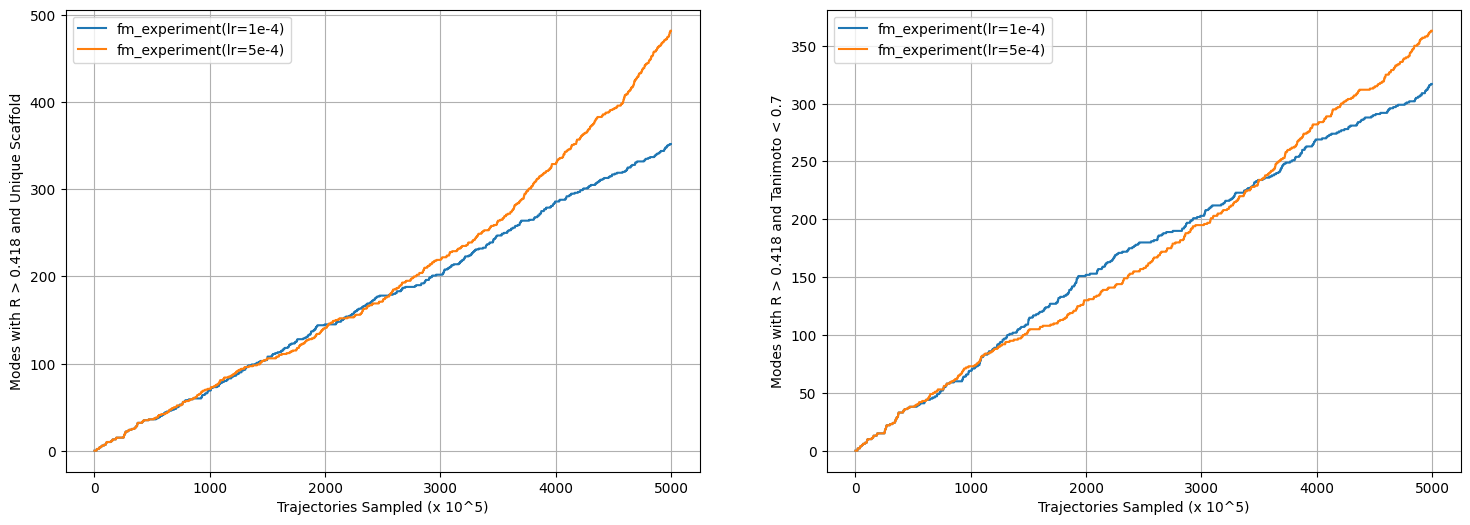

<Figure size 640x480 with 0 Axes>

In [7]:
ids = ["fm_experiment(lr=1e-4)", "fm_experiment(lr=5e-4)"]
plot_modes(ids)

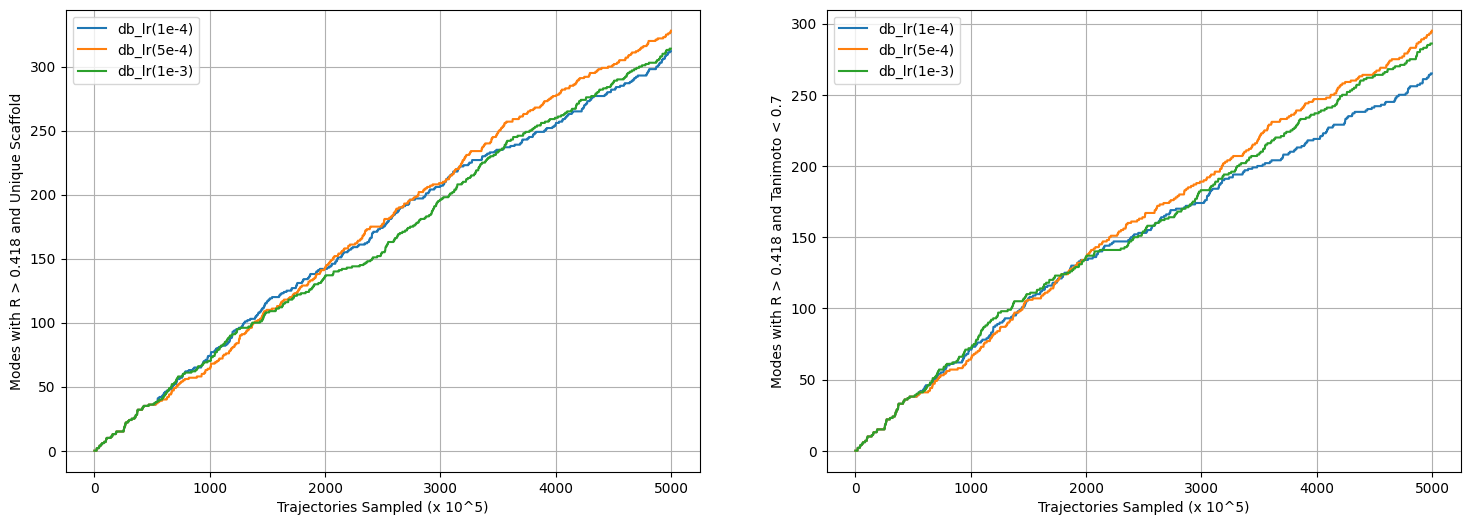

<Figure size 640x480 with 0 Axes>

In [8]:
ids = ["db_lr(1e-4)", "db_lr(5e-4)", "db_lr(1e-3)"]
plot_modes(ids)

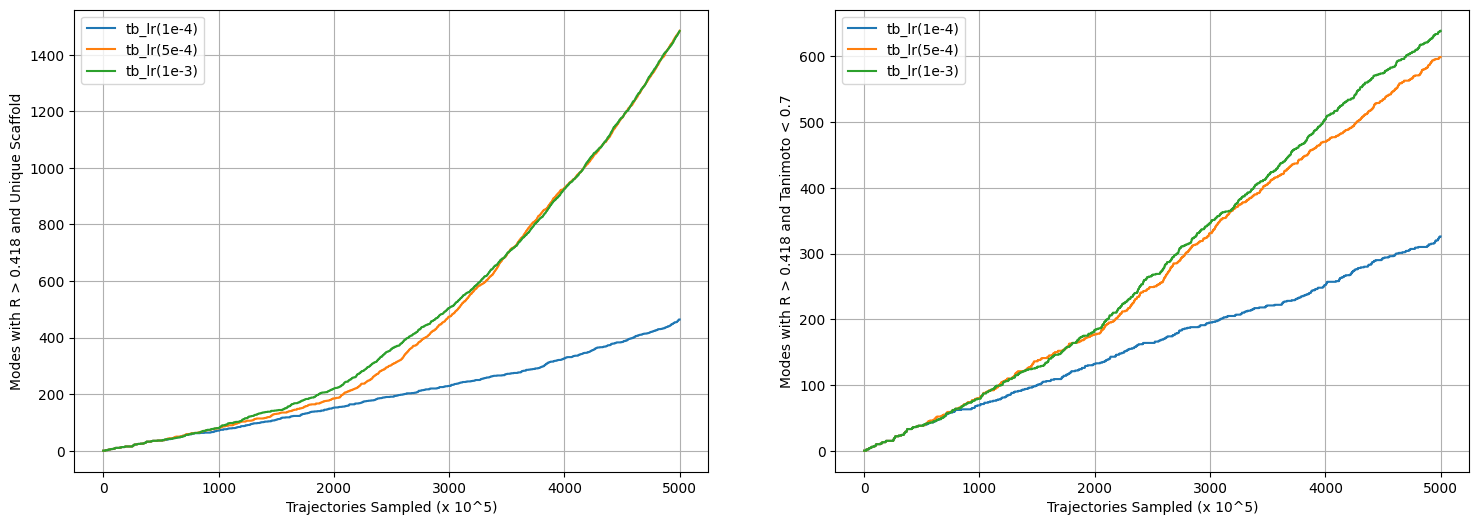

<Figure size 640x480 with 0 Axes>

In [135]:
ids = ["tb_lr(1e-4)", "tb_lr(5e-4)", "tb_lr(1e-3)"]
plot_modes(ids)

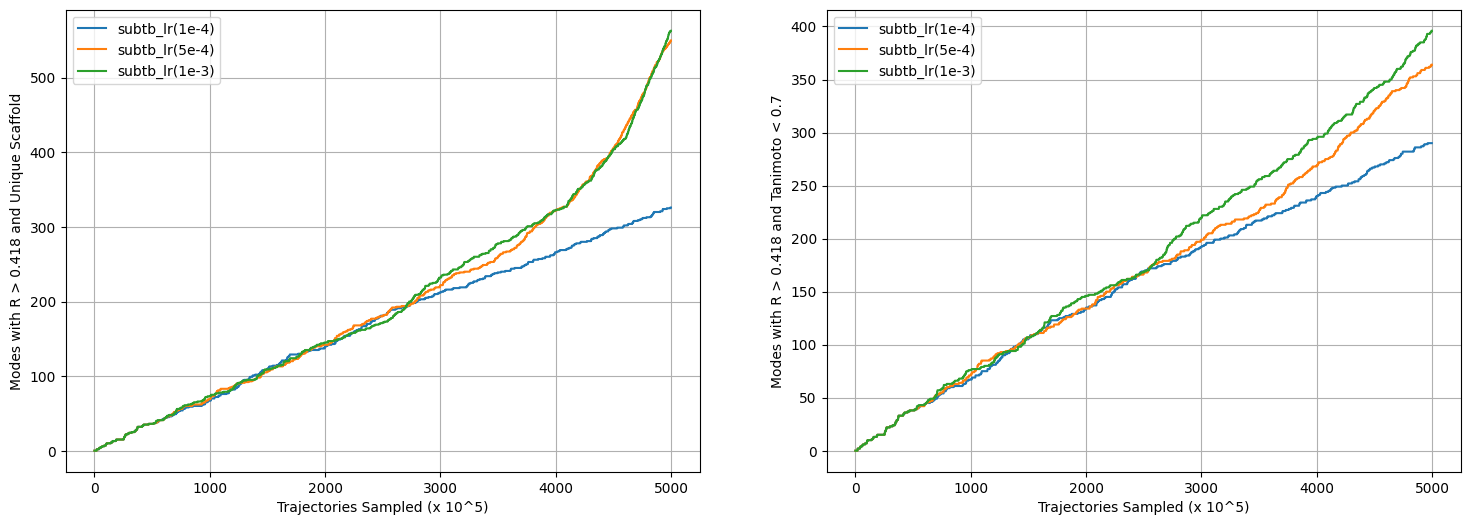

<Figure size 640x480 with 0 Axes>

In [138]:
ids = ["subtb_lr(1e-4)", "subtb_lr(5e-4)", "subtb_lr(1e-3)"]
plot_modes(ids)

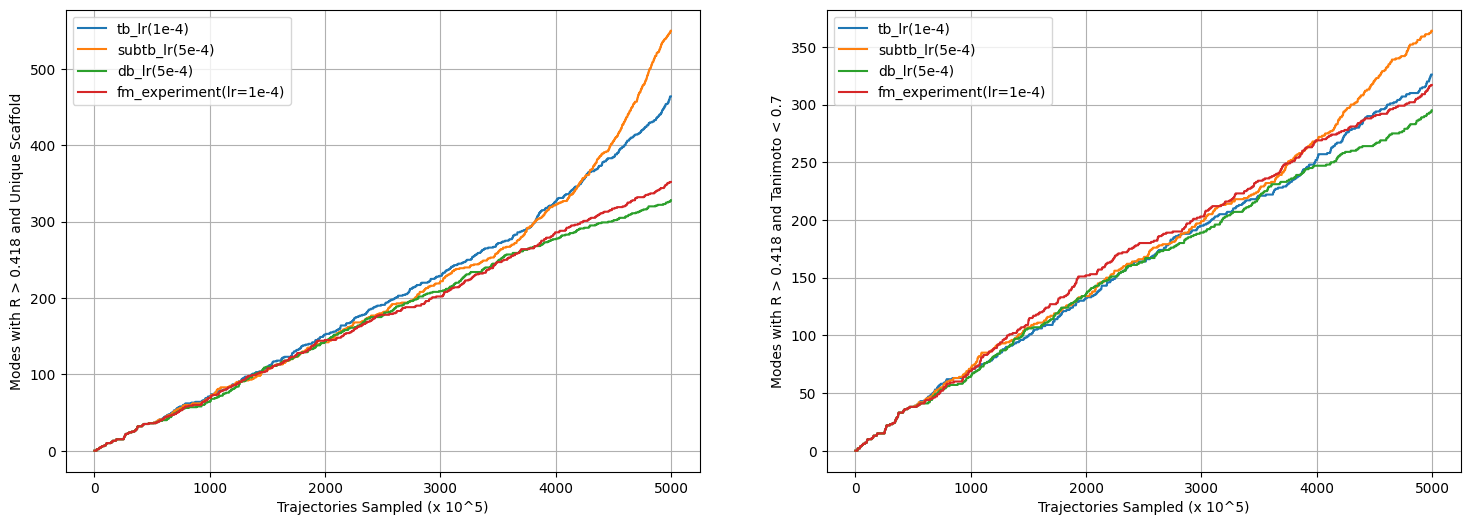

<Figure size 640x480 with 0 Axes>

In [139]:
ids = ["tb_lr(1e-4)", "subtb_lr(5e-4)", "db_lr(5e-4)", "fm_experiment(lr=1e-4)"]
plot_modes(ids)

### log(P(x)) - log(R) plots with pearson

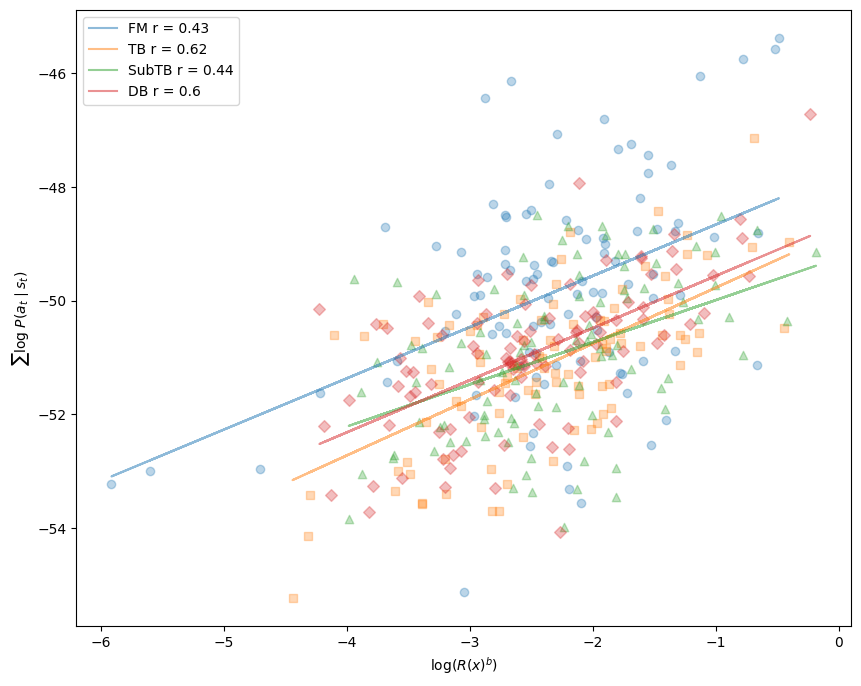

In [10]:
ids = ["fm_experiment(lr=1e-4)", "tb_lr(1e-4)", "subtb_lr(1e-4)", "db_lr(1e-4)"]
names = ["FM", "TB", "SubTB", "DB"]
markers = ['o', 's', '^', 'D']
current_dir = Path().resolve().parent
proxy_model = load_proxy_sol()
proxy_model.eval()

plt.figure(figsize=(10, 8))

for i,id in enumerate(ids):
    yaml_dir = current_dir / "src" / "gflownet" / "tasks" / "logs" / id / "config.yaml"
    model_dir = current_dir / "src" / "gflownet" / "tasks" / "logs" / id / "model_state.pt"
    cfg = OmegaConf.load(yaml_dir)
    # Load env
    env = GraphBuildingEnv()
    temp_cond = TemperatureConditional(cfg)
    num_cond_dim = temp_cond.encoding_size()
    ctx = FragMolBuildingEnvContext(
        max_frags=cfg.algo.max_nodes,
        num_cond_dim=num_cond_dim,
        fragments=bengio2021flow.FRAGMENTS,
    )
    # Load GFN Model
    model = GraphTransformerGFN(
        env_ctx=ctx,
        cfg=cfg,
        num_graph_out=cfg.algo.tb.do_predict_n + 1,
        do_bck=cfg.algo.tb.do_parameterize_p_b,
    )
    model.load_state_dict((torch.load(model_dir)["models_state_dict"][0])) 
    model.eval()
    # Load Algo
    if cfg.algo.method == "FM":
        algo = TrajectoryBalance(env, ctx, cfg)
    else:
        algo = FlowMatching(env, ctx, cfg)
    # Load cond_info
    seed = 42
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    num_gen = 100
    cond_info = temp_cond.sample(num_gen)["encoding"]
    samples = algo.create_training_data_from_own_samples(model=model, n=num_gen, cond_info=cond_info)
    trajectories = [sample["traj"] for sample in samples]
    rdkit_mols = [ctx.graph_to_obj(traj[-1][0]) for traj in trajectories]
    smiles = [Chem.MolToSmiles(mol) for mol in rdkit_mols]
    # Get preds
    graphs = [smiles2graph(Chem.MolFromSmiles(smile)) for smile in smiles]
    batch = gd.Batch.from_data_list([g for g in graphs if g is not None])
    preds = proxy_model(batch.x, batch.edge_index, batch.edge_attr, batch.batch).squeeze(dim=-1).cpu().detach().numpy()
    min_logp = -13.71
    max_logp = 2.41
    scaled_preds = list(1 - ((preds - min_logp) / (max_logp - min_logp)))
    scaled_preds = [sc**4 for sc in scaled_preds]
    log_rew = np.log(scaled_preds)
    policy = [p["fwd_logprob"].item() for p in samples]

    pearson_corr, _ = pearsonr(log_rew, policy)

    slope, intercept = np.polyfit(log_rew, policy, 1)
    line = slope * np.array(log_rew) + intercept
    plt.scatter(log_rew, policy, alpha=0.3, marker=markers[i])
    plt.plot(log_rew, line, label=f"{names[i]} r = {round(pearson_corr, 2)}", linestyle="-", alpha = 0.5)
    
plt.xlabel(r"$\log(R(x)^b)$")
plt.ylabel(r'$\sum\log\, P(a_t \mid s_t)$')
plt.legend()
plt.show()

### Generate final table

In [ ]:
def generate_maccs_fingerprint(smiles):
            mol = Chem.MolFromSmiles(smiles)
            fingerprint = MACCSkeys.GenMACCSKeys(mol)
            return fingerprint

def top_k_tanimoto(smiles, k):
    maccs_fingerprints = [generate_maccs_fingerprint(smile) for smile in smiles[:k]]
    n_samples = len(maccs_fingerprints)
    similarity_matrix = np.zeros((n_samples, n_samples))
    for i in range(n_samples):
        for j in range(i, n_samples):
            similarity = DataStructs.TanimotoSimilarity(maccs_fingerprints[i], maccs_fingerprints[j])
            similarity_matrix[i, j] = similarity
            similarity_matrix[j, i] = similarity 
    upper_triangular = similarity_matrix[np.triu_indices_from(similarity_matrix, k=1)]
    average_similarity = np.mean(upper_triangular)
    return average_similarity

def top_k_reward(preds, k):
    scaled_preds = scale_rew(preds)[:k]
    return np.mean(scaled_preds)

In [36]:
ids = ["fm_experiment(lr=1e-4)"]#, "tb_lr(1e-4)", "subtb_lr(1e-4)", "db_lr(1e-4)"]
for i,id in enumerate(ids):
    yaml_dir = current_dir / "src" / "gflownet" / "tasks" / "logs" / id / "config.yaml"
    model_dir = current_dir / "src" / "gflownet" / "tasks" / "logs" / id / "model_state.pt"
    cfg = OmegaConf.load(yaml_dir)
    # Load env
    env = GraphBuildingEnv()
    temp_cond = TemperatureConditional(cfg)
    num_cond_dim = temp_cond.encoding_size()
    ctx = FragMolBuildingEnvContext(
        max_frags=cfg.algo.max_nodes,
        num_cond_dim=num_cond_dim,
        fragments=bengio2021flow.FRAGMENTS,
    )
    # Load GFN Model
    model = GraphTransformerGFN(
        env_ctx=ctx,
        cfg=cfg,
        num_graph_out=cfg.algo.tb.do_predict_n + 1,
        do_bck=cfg.algo.tb.do_parameterize_p_b,
    )
    model.load_state_dict((torch.load(model_dir)["models_state_dict"][0])) 
    model.eval()
    # Load Algo
    if cfg.algo.method == "FM":
        algo = TrajectoryBalance(env, ctx, cfg)
    else:
        algo = FlowMatching(env, ctx, cfg)
    # Load cond_info
    seeds = [42, 43, 44]
    table = dict()
    table["Top 100 tanimoto"] = []
    table["Top 1000 tanimoto"] = []
    table["Top 100 diverse"] = []
    table["Top 1000 diverse"] = []
    table["Top 100 reward"] = []
    table["Top 1000 reward"] = []
    for seed in seeds:
        random.seed(seed)
        np.random.seed(seed)
        torch.manual_seed(seed)
        num_gen = 10
        cond_info = temp_cond.sample(num_gen)["encoding"]
        samples = algo.create_training_data_from_own_samples(model=model, n=num_gen, cond_info=cond_info)
        trajectories = [sample["traj"] for sample in samples]
        rdkit_mols = [ctx.graph_to_obj(traj[-1][0]) for traj in trajectories]
        smiles = [Chem.MolToSmiles(mol) for mol in rdkit_mols]
        # Get preds
        graphs = [smiles2graph(Chem.MolFromSmiles(smile)) for smile in smiles]
        batch = gd.Batch.from_data_list([g for g in graphs if g is not None])
        with torch.no_grad():
            preds = proxy_model(batch.x, batch.edge_index, batch.edge_attr, batch.batch).squeeze(dim=-1).cpu().numpy()
        sm_pr_df = pd.DataFrame({"smiles": smiles, "preds": preds})
        sm_pr_df = sm_pr_df.sort_values(by="preds", ascending=True)
        sm_pr_df = sm_pr_df.reset_index(drop=True)
        table["Top 100 tanimoto"].append(top_k_tanimoto(sm_pr_df["smiles"], 100))
        table["Top 1000 tanimoto"].append(top_k_tanimoto(sm_pr_df["smiles"], 1000))
        table["Top 100 reward"].append(top_k_reward(sm_pr_df["preds"], 100))
        table["Top 1000 reward"].append(top_k_reward(sm_pr_df["preds"], 1000))

In [38]:
smiles

['CC(C)=CC1CCCC(C2CCCCC2)C1c1cccc(-c2ccccn2)c1C1CCCCC1',
 'CC(C)=CC1CCC(c2cccc(-c3cc(-c4ccncn4)c4ccccc4c3)c2)C(c2ccncc2)O1',
 'C1=C(c2ccc(C3CCCCC3C3CCCCC3C3CCCC(c4ccccc4)C3)nc2)CCCC1',
 'N#CC1CCC(c2ccc(C3CCCC(C4CCCC(c5ccccc5)C4)C3)cc2)OC1',
 'O=[SH](=O)c1cc(C2CCOCC2c2ccccc2-c2cc(-c3cccnc3)ccn2)ccn1',
 'CC(O)c1cc(-c2ccc(-c3ccccc3)cc2-c2ncc(C3C=CCCC3)cn2)c2ccccc2c1',
 'C1=C(c2cncnc2)CCC(c2ccc(C3CCOC3)c(C3CCNCC3)c2)C1c1ccccc1',
 'c1ccc(-c2cccc(-c3ccccc3-c3cccc(-c4cccc(-c5ccncc5)c4)c3)c2)cc1',
 'c1ccc(C2CCCCC2c2ccccc2C2CCCC(C3CCCCC3)C2)c(C2CCOCC2)c1',
 'c1ccc(-c2cccc(-c3ccccc3C3OCC(c4ccncn4)C3c3ccccc3)c2)cc1']